In [1]:
# %%capture cap
!pip install -q ipywidgets
!pip install -q autogluon scikit-learn==1.5.2 
!apt-get install -q -y graphviz graphviz-dev && pip install -q pydot
!pip install -q pygraphviz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 8.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.9/454.9 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.3/487.3 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.7/189.7 kB 11.8 MB/s eta 0:0

In [2]:
import torch
import os
import pydot

import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from time import time, sleep
from itertools import combinations

from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

## -- Set Global Seed --
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

pd.set_option('display.max_columns', 500)
# plt.style.use("ggplot")
# sns.set_style("whitegrid")

## -- Ansi color codes --
COLOR = '\033[32m'
RESET = '\033[0m'

print("Packages import succesful!")

Packages import succesful!


In [3]:
### Load Data ###
PATH = '/kaggle/input/playground-series-s5e12/'
submit = pd.read_csv(PATH+'sample_submission.csv')
tn = pd.read_csv(PATH+"train.csv").drop('id', axis=1)

TARGET = tn.columns[-1]
TARGET

'diagnosed_diabetes'

In [4]:
folder_path = '/kaggle/input/ps5e12-oof-for-ensemble'

train = pd.DataFrame()
test = pd.DataFrame()

print("Loading .npy: ", end="")
for (root, dirs, files) in os.walk(folder_path):
    for i, file in enumerate(sorted(files), 1):
        if i%5 == 0: print(f"{i}%.. ", end="")
        if file.endswith(".npy") and "oof" in file:
            train_path = np.load(os.path.join(root, file))
            train = pd.concat([train, pd.Series(train_path, name=file[4:-4])], axis=1)
        elif file.endswith(".npy") and "pred" in file:
            test_path = np.load(os.path.join(root, file))
            test = pd.concat([test, pd.Series(test_path, name=file[5:-4])], axis=1)
print()
print("Loading .parquet files: ", end="")
for (root, dirs, files) in os.walk(folder_path):
    for i, file in enumerate(sorted(files), 1):
        if i%5 == 0: print(f"{i}%.. ", end="")
        if file.endswith(".parquet") and "oof" in file:
            train_path = os.path.join(root, file)
            train = pd.concat([train, pd.read_parquet(train_path)], axis=1)
        elif file.endswith(".parquet") and "pred" in file:
            test_path = os.path.join(root, file)
            test = pd.concat([test, pd.read_parquet(test_path)], axis=1)
print()

## -- Drop columns from train
for df in [train, test]:
    drop_cols = [col for col in df.columns if 'L3' in col or 'L2' in col]
    df.drop(drop_cols, axis=1, inplace=True)

print(f"OOFs models: {len(train.columns)} || Shape: {train.shape}")
print(f"PRED models: {len(test.columns)} || Shape: {test.shape}")

display(train.head())
display(test.head())

Loading .npy: 5%.. 10%.. 15%.. 20%.. 25%.. 5%.. 10%.. 15%.. 
Loading .parquet files: 5%.. 10%.. 15%.. 20%.. 25%.. 5%.. 10%.. 15%.. 
OOFs models: 62 || Shape: (700000, 62)
PRED models: 62 || Shape: (300000, 62)


,LGB_cv10_7317,LGB_cv10_73188,XGB_cv10_73187,XGB_cv10_73193,hist_73031,lgb_TD_FE_CROSS_ENT_cv10_73029,lgb_TD_FE_cv10_7305,lgb_TD_cv10_73026,tabM_AUC_OVR_cv10_69934,tabM_D_FE_cv10_73029,tabM_ENTROPY_cv10_69908,xgb_TD_FE_CROSS_ENT_cv10_72955,xgb_TD_FE_cv10_72972,xgb_TD_cv10_7296,loglbf_seed42_72989,loglbf_seed42_73006,loglbf_seed77_72989,loglin_seed24_72989,loglin_seed24_73003,loglin_seed24_73006,loglin_seed99_72989,loglin_seed99_72991,loglin_seed99_72997,LightGBMXTBAGL1,LightGBMBAGL1,RandomForestGiniBAGL1,RandomForestEntrBAGL1,CatBoostBAGL1,ExtraTreesGiniBAGL1,ExtraTreesEntrBAGL1,NeuralNetFastAIBAGL1,XGBoostBAGL1,LightGBMLargeBAGL1,LightGBMXTBAGL1,LightGBMBAGL1,RandomForestGiniBAGL1,RandomForestEntrBAGL1,CatBoostBAGL1,ExtraTreesGiniBAGL1,ExtraTreesEntrBAGL1,NeuralNetFastAIBAGL1,XGBoostBAGL1,LightGBMXTBAGL1PSEUDO,LightGBMBAGL1PSEUDO,RandomForestGiniBAGL1PSEUDO,RandomForestEntrBAGL1PSEUDO,CatBoostBAGL1PSEUDO,ExtraTreesGiniBAGL1PSEUDO,ExtraTreesEntrBAGL1PSEUDO,NeuralNetFastAIBAGL1PSEUDO,XGBoostBAGL1PSEUDO,LightGBMLargeBAGL1PSEUDO,LightGBMXTBAGL1,LightGBMBAGL1,RandomForestGiniBAGL1,RandomForestEntrBAGL1,CatBoostBAGL1,ExtraTreesGiniBAGL1,ExtraTreesEntrBAGL1,NeuralNetFastAIBAGL1,XGBoostBAGL1,LightGBMLargeBAGL1
0,0.477892,0.490867,0.479570,0.487639,0.500055,0.478102,0.483941,0.462582,0.599961,0.484882,0.608077,0.436054,0.479392,0.446476,0.470490,0.484471,0.470490,0.470304,0.477333,0.484452,0.470304,0.471379,0.473578,0.536769,0.538501,0.629204,0.580444,0.528528,0.581862,0.574100,0.560666,0.600537,0.554989,0.536769,0.538501,0.629204,0.580444,0.534444,0.581862,0.574100,0.642780,0.608866,0.568928,0.553153,0.546378,0.604113,0.543152,0.608727,0.567993,0.531691,0.609384,0.597585,0.542926,0.567537,0.596196,0.516828,0.514819,0.528700,0.556199,0.509301,0.576514,0.619563
1,0.628203,0.627667,0.617412,0.622584,0.630908,0.583936,0.625409,0.609117,0.584066,0.608751,0.584290,0.623157,0.625883,0.614109,0.609004,0.613386,0.609004,0.608901,0.611594,0.613257,0.608901,0.609237,0.610505,0.644945,0.598300,0.611081,0.618544,0.629780,0.615771,0.598512,0.592651,0.613654,0.615174,0.644945,0.598300,0.611081,0.618544,0.630118,0.615771,0.598512,0.598862,0.616805,0.626692,0.603201,0.657404,0.625413,0.638447,0.594893,0.606830,0.649743,0.615660,0.632525,0.610469,0.617477,0.703523,0.640271,0.648169,0.624301,0.623661,0.557733,0.629099,0.624685
2,0.208956,0.207935,0.225456,0.212888,0.180894,0.175855,0.202418,0.173956,0.251782,0.184742,0.244601,0.165297,0.186631,0.196787,0.192549,0.213629,0.192549,0.192620,0.203151,0.213548,0.192620,0.193831,0.197563,0.216969,0.226389,0.304067,0.352671,0.197099,0.376881,0.401807,0.255465,0.393524,0.255500,0.216969,0.226389,0.304067,0.352671,0.188754,0.376881,0.401807,0.286088,0.491119,0.257268,0.232222,0.328749,0.305510,0.222700,0.407693,0.400686,0.270508,0.449145,0.343150,0.231538,0.260525,0.256762,0.280756,0.203621,0.344695,0.315725,0.296905,0.414031,0.542024
3,0.471177,0.480236,0.498995,0.498886,0.476986,0.511201,0.492000,0.492369,0.575673,0.501406,0.587889,0.520196,0.482299,0.479687,0.485364,0.498813,0.485364,0.485326,0.492303,0.498392,0.485326,0.486143,0.488752,0.485717,0.471010,0.574364,0.544550,0.478353,0.606121,0.601856,0.484891,0.601952,0.496528,0.485717,0.471010,0.574364,0.544550,0.483186,0.606121,0.601856,0.495730,0.612595,0.490217,0.482713,0.585351,0.564321,0.488810,0.611997,0.597079,0.364687,0.611470,0.514035,0.485575,0.489804,0.508599,0.504376,0.494640,0.572931,0.576757,0.512527,0.588185,0.622198
4,0.833563,0.830755,0.840959,0.831876,0.818191,0.830675,0.855325,0.841989,0.746104,0.808829,0.755913,0.866760,0.824807,0.840663,0.814294,0.792911,0.814294,0.814360,0.803389,0.793180,0.814360,0.813081,0.809414,0.832226,0.842886,0.761858,0.705647,0.838652,0.705309,0.690164,0.774309,0.683667,0.849399,0.832226,0.842886,0.761858,0.705647,0.831563,0.705309,0.690164,0.819500,0.662832,0.821873,0.842256,0.757796,0.745142,0.827960,0.702239,0.696150,0.826038,0.681737,0.778543,0.859378,0.848054,0.738659,0.752610,0.832809,0.693804,0.701839,0.82

,LGB_cv10_7317,LGB_cv10_73188,XGB_cv10_73187,XGB_cv10_73193,hist_73031,lgb_TD_FE_CROSS_ENT_cv10_73029,lgb_TD_FE_cv10_7305,lgb_TD_cv10_73026,tabM_AUC_OVR_cv10_69934,tabM_D_FE_cv10_73029,tabM_ENTROPY_cv10_69908,xgb_TD_FE_CROSS_ENT_cv10_72955,xgb_TD_FE_cv10_72972,xgb_TD_cv10_7296,loglbf_seed42_72989,loglbf_seed42_73006,loglbf_seed77_72989,loglin_seed24_72989,loglin_seed24_73003,loglin_seed24_73006,loglin_seed99_72989,loglin_seed99_72991,loglin_seed99_72997,LightGBMXTBAGL1,LightGBMBAGL1,RandomForestGiniBAGL1,RandomForestEntrBAGL1,CatBoostBAGL1,ExtraTreesGiniBAGL1,ExtraTreesEntrBAGL1,NeuralNetFastAIBAGL1,XGBoostBAGL1,LightGBMLargeBAGL1,LightGBMXTBAGL1,LightGBMBAGL1,RandomForestGiniBAGL1,RandomForestEntrBAGL1,CatBoostBAGL1,ExtraTreesGiniBAGL1,ExtraTreesEntrBAGL1,NeuralNetFastAIBAGL1,XGBoostBAGL1,LightGBMXTBAGL1PSEUDO,LightGBMBAGL1PSEUDO,RandomForestGiniBAGL1PSEUDO,RandomForestEntrBAGL1PSEUDO,CatBoostBAGL1PSEUDO,ExtraTreesGiniBAGL1PSEUDO,ExtraTreesEntrBAGL1PSEUDO,NeuralNetFastAIBAGL1PSEUDO,XGBoostBAGL1PSEUDO,LightGBMLargeBAGL1PSEUDO,LightGBMXTBAGL1,LightGBMBAGL1,RandomForestGiniBAGL1,RandomForestEntrBAGL1,CatBoostBAGL1,ExtraTreesGiniBAGL1,ExtraTreesEntrBAGL1,NeuralNetFastAIBAGL1,XGBoostBAGL1,LightGBMLargeBAGL1
0,0.463984,0.465584,0.465424,0.463791,0.498487,0.487713,0.474670,0.485141,0.550886,0.476769,0.550028,0.467071,0.471312,0.500130,0.464884,0.482729,0.464884,0.464912,0.474067,0.482473,0.464912,0.465995,0.469140,0.461216,0.463329,0.525045,0.537416,0.472589,0.533644,0.540919,0.534583,0.531346,0.487164,0.461216,0.463329,0.525045,0.537416,0.487909,0.533644,0.540919,0.485699,0.569283,0.454026,0.441687,0.560622,0.514647,0.460189,0.536640,0.524299,0.472894,0.530921,0.516811,0.462776,0.465925,0.540035,0.505078,0.465048,0.501139,0.527550,0.461735,0.564474,0.612961
1,0.719675,0.717735,0.717488,0.706441,0.712424,0.713479,0.713693,0.720893,0.577157,0.710706,0.572853,0.707881,0.702087,0.725184,0.721635,0.702869,0.721635,0.721635,0.711852,0.703154,0.721635,0.720473,0.716927,0.714165,0.715755,0.551301,0.604181,0.748314,0.563997,0.562311,0.727721,0.572120,0.681501,0.714165,0.715755,0.551301,0.604181,0.741174,0.563997,0.562311,0.731859,0.592986,0.700130,0.697688,0.573166,0.557730,0.725650,0.555731,0.567476,0.704483,0.573312,0.653334,0.706367,0.721918,0.591107,0.562768,0.713729,0.556451,0.546048,0.730421,0.609008,0.624924
2,0.798833,0.799934,0.793531,0.794226,0.793188,0.785949,0.780439,0.785096,0.655886,0.789209,0.657226,0.794665,0.788392,0.781128,0.784230,0.772006,0.784230,0.784162,0.777869,0.772408,0.784162,0.783443,0.781107,0.764285,0.755733,0.692470,0.693391,0.807456,0.629507,0.615816,0.784491,0.624398,0.748979,0.764285,0.755733,0.692470,0.693391,0.795563,0.629507,0.615816,0.783396,0.624695,0.760988,0.748779,0.682468,0.654536,0.793862,0.631076,0.628693,0.750764,0.620200,0.694929,0.758936,0.751065,0.728621,0.695317,0.810545,0.653577,0.654662,0.771888,0.634128,0.630764
3,0.373855,0.377529,0.375776,0.384059,0.384506,0.376524,0.382691,0.374700,0.551839,0.395962,0.553524,0.375991,0.374372,0.372963,0.387180,0.409850,0.387180,0.387218,0.398411,0.410226,0.387218,0.388538,0.392170,0.386793,0.379353,0.527617,0.493676,0.368872,0.604702,0.609410,0.404877,0.586561,0.427294,0.386793,0.379353,0.527617,0.493676,0.386587,0.604702,0.609410,0.382933,0.611201,0.392154,0.384248,0.501133,0.523837,0.374002,0.619656,0.613550,0.381398,0.593713,0.494366,0.391841,0.389578,0.444758,0.431383,0.367516,0.533837,0.525412,0.420271,0.544109,0.606830
4,0.927499,0.932051,0.930458,0.934048,0.901513,0.907557,0.907353,0.910353,0.847159,0.905428,0.851712,0.922649,0.907369,0.921191,0.930757,0.905353,0.930757,0.930704,0.918127,0.905666,0.930704,0.929232,0.925008,0.898859,0.898528,0.834049,0.839531,0.931732,0.770344,0.781955,0.921921,0.739739,0.855575,0.898859,0.898528,0.834049,0.839531,0.923809,0.770344,0.781955,0.922287,0.691785,0.865112,0.869920,0.815494,0.792928,0.887805,0.741348,0.740149,0.901037,0.717323,0.752887,0.899398,0.899175,0.844317,0.854814,0.925129,0.792099,0.795596,0.91

In [5]:
def rename_duplicate_cols(df: pd.DataFrame) -> pd.DataFrame:
    original_cols = list(df.columns)
    new_cols = []
    # Track how many times we've seen each original name
    seen = {}

    for col in tqdm(original_cols, desc="Fixing columns"):
        if col not in seen:
            # First occurrence: keep name unchanged
            seen[col] = 1
            new_cols.append(col)
        else:
            # Duplicate: append suffix _k where k starts at 0
            suffix = seen[col] - 1 # 0 for first duplicate, 1 for second,
            new_name = f"{col}_{suffix}"
            new_cols.append(new_name)
            seen[col] += 1

    # Apply new column names
    df = df.copy()
    df.columns = new_cols
    print(f"{COLOR}Columns fixed!!!{RESET}")

    return df

In [6]:
train = rename_duplicate_cols(train)
test = rename_duplicate_cols(test)

Fixing columns:   0%|          | 0/62 [00:00<?, ?it/s]

Columns fixed!!!


Fixing columns:   0%|          | 0/62 [00:00<?, ?it/s]

Columns fixed!!!


In [7]:
train = pd.concat([train, tn[TARGET]], axis=1)

display(train.head())
train.info()

,LGB_cv10_7317,LGB_cv10_73188,XGB_cv10_73187,XGB_cv10_73193,hist_73031,lgb_TD_FE_CROSS_ENT_cv10_73029,lgb_TD_FE_cv10_7305,lgb_TD_cv10_73026,tabM_AUC_OVR_cv10_69934,tabM_D_FE_cv10_73029,tabM_ENTROPY_cv10_69908,xgb_TD_FE_CROSS_ENT_cv10_72955,xgb_TD_FE_cv10_72972,xgb_TD_cv10_7296,loglbf_seed42_72989,loglbf_seed42_73006,loglbf_seed77_72989,loglin_seed24_72989,loglin_seed24_73003,loglin_seed24_73006,loglin_seed99_72989,loglin_seed99_72991,loglin_seed99_72997,LightGBMXTBAGL1,LightGBMBAGL1,RandomForestGiniBAGL1,RandomForestEntrBAGL1,CatBoostBAGL1,ExtraTreesGiniBAGL1,ExtraTreesEntrBAGL1,NeuralNetFastAIBAGL1,XGBoostBAGL1,LightGBMLargeBAGL1,LightGBMXTBAGL1_0,LightGBMBAGL1_0,RandomForestGiniBAGL1_0,RandomForestEntrBAGL1_0,CatBoostBAGL1_0,ExtraTreesGiniBAGL1_0,ExtraTreesEntrBAGL1_0,NeuralNetFastAIBAGL1_0,XGBoostBAGL1_0,LightGBMXTBAGL1PSEUDO,LightGBMBAGL1PSEUDO,RandomForestGiniBAGL1PSEUDO,RandomForestEntrBAGL1PSEUDO,CatBoostBAGL1PSEUDO,ExtraTreesGiniBAGL1PSEUDO,ExtraTreesEntrBAGL1PSEUDO,NeuralNetFastAIBAGL1PSEUDO,XGBoostBAGL1PSEUDO,LightGBMLargeBAGL1PSEUDO,LightGBMXTBAGL1_1,LightGBMBAGL1_1,RandomForestGiniBAGL1_1,RandomForestEntrBAGL1_1,CatBoostBAGL1_1,ExtraTreesGiniBAGL1_1,ExtraTreesEntrBAGL1_1,NeuralNetFastAIBAGL1_1,XGBoostBAGL1_1,LightGBMLargeBAGL1_0,diagnosed_diabetes
0,0.477892,0.490867,0.479570,0.487639,0.500055,0.478102,0.483941,0.462582,0.599961,0.484882,0.608077,0.436054,0.479392,0.446476,0.470490,0.484471,0.470490,0.470304,0.477333,0.484452,0.470304,0.471379,0.473578,0.536769,0.538501,0.629204,0.580444,0.528528,0.581862,0.574100,0.560666,0.600537,0.554989,0.536769,0.538501,0.629204,0.580444,0.534444,0.581862,0.574100,0.642780,0.608866,0.568928,0.553153,0.546378,0.604113,0.543152,0.608727,0.567993,0.531691,0.609384,0.597585,0.542926,0.567537,0.596196,0.516828,0.514819,0.528700,0.556199,0.509301,0.576514,0.619563,1.0
1,0.628203,0.627667,0.617412,0.622584,0.630908,0.583936,0.625409,0.609117,0.584066,0.608751,0.584290,0.623157,0.625883,0.614109,0.609004,0.613386,0.609004,0.608901,0.611594,0.613257,0.608901,0.609237,0.610505,0.644945,0.598300,0.611081,0.618544,0.629780,0.615771,0.598512,0.592651,0.613654,0.615174,0.644945,0.598300,0.611081,0.618544,0.630118,0.615771,0.598512,0.598862,0.616805,0.626692,0.603201,0.657404,0.625413,0.638447,0.594893,0.606830,0.649743,0.615660,0.632525,0.610469,0.617477,0.703523,0.640271,0.648169,0.624301,0.623661,0.557733,0.629099,0.624685,1.0
2,0.208956,0.207935,0.225456,0.212888,0.180894,0.175855,0.202418,0.173956,0.251782,0.184742,0.244601,0.165297,0.186631,0.196787,0.192549,0.213629,0.192549,0.192620,0.203151,0.213548,0.192620,0.193831,0.197563,0.216969,0.226389,0.304067,0.352671,0.197099,0.376881,0.401807,0.255465,0.393524,0.255500,0.216969,0.226389,0.304067,0.352671,0.188754,0.376881,0.401807,0.286088,0.491119,0.257268,0.232222,0.328749,0.305510,0.222700,0.407693,0.400686,0.270508,0.449145,0.343150,0.231538,0.260525,0.256762,0.280756,0.203621,0.344695,0.315725,0.296905,0.414031,0.542024,0.0
3,0.471177,0.480236,0.498995,0.498886,0.476986,0.511201,0.492000,0.492369,0.575673,0.501406,0.587889,0.520196,0.482299,0.479687,0.485364,0.498813,0.485364,0.485326,0.492303,0.498392,0.485326,0.486143,0.488752,0.485717,0.471010,0.574364,0.544550,0.478353,0.606121,0.601856,0.484891,0.601952,0.496528,0.485717,0.471010,0.574364,0.544550,0.483186,0.606121,0.601856,0.495730,0.612595,0.490217,0.482713,0.585351,0.564321,0.488810,0.611997,0.597079,0.364687,0.611470,0.514035,0.485575,0.489804,0.508599,0.504376,0.494640,0.572931,0.576757,0.512527,0.588185,0.622198,1.0
4,0.833563,0.830755,0.840959,0.831876,0.818191,0.830675,0.855325,0.841989,0.746104,0.808829,0.755913,0.866760,0.824807,0.840663,0.814294,0.792911,0.814294,0.814360,0.803389,0.793180,0.814360,0.813081,0.809414,0.832226,0.842886,0.761858,0.705647,0.838652,0.705309,0.690164,0.774309,0.683667,0.849399,0.832226,0.842886,0.761858,0.705647,0.831563,0.705309,0.690164,0.819500,0.662832,0.821873,0.842256,0.757796,0.745142,0.827960,0.702239,0.696150,0.826038,0.681737,0.7

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 63 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   LGB_cv10_7317                   700000 non-null  float64
 1   LGB_cv10_73188                  700000 non-null  float64
 2   XGB_cv10_73187                  700000 non-null  float64
 3   XGB_cv10_73193                  700000 non-null  float64
 4   hist_73031                      700000 non-null  float64
 5   lgb_TD_FE_CROSS_ENT_cv10_73029  700000 non-null  float64
 6   lgb_TD_FE_cv10_7305             700000 non-null  float64
 7   lgb_TD_cv10_73026               700000 non-null  float64
 8   tabM_AUC_OVR_cv10_69934         700000 non-null  float64
 9   tabM_D_FE_cv10_73029            700000 non-null  float64
 10  tabM_ENTROPY_cv10_69908         700000 non-null  float64
 11  xgb_TD_FE_CROSS_ENT_cv10_72955  700000 non-null  float64
 12  xgb_TD_FE_cv10_7

In [8]:
MODELS_PATH = "/kaggle/working/AG_DIABETES_models/"
# !rm -r {MODELS_PATH}

In [9]:
from autogluon.tabular import TabularPredictor

In [10]:
## -- RUN 1: Use train data -- 
predictor = TabularPredictor(
                label = TARGET,
         problem_type = "binary",
          eval_metric = "roc_auc",
                 path = MODELS_PATH,
    ).fit(
                   train_data = train,
                      presets = "best",
                num_bag_folds = 5,
             # dynamic_stacking = False,
             # num_stack_levels = 1,
                   time_limit = 3600*11,
                   # auto_stack = False,
                 # num_bag_sets = 2,
                  # ag_args_fit = {'num_cpus': os.cpu_count()},
) 

Preset alias specified: 'best' maps to 'best_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.11.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Sat Sep 27 10:16:09 UTC 2025
CPU Count:          4
Memory Avail:       29.15 GB / 31.35 GB (93.0%)
Disk Space Avail:   19.50 GB / 19.52 GB (99.9%)
Presets specified: ['best']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=5, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon w

In [11]:
## -- Get Summary -- 
print(f"-> Total models : {len(predictor.model_names())}")
print(f"-> Best model   : {predictor.model_best}\n") 

## -- RUN 1 RESULTS -- 
leaderboard = predictor.leaderboard(silent=True)
leaderboard.style.background_gradient(subset=["score_val"], cmap="Spectral")

-> Total models : 33
-> Best model   : WeightedEnsemble_L3



,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L3,0.732843,roc_auc,533.822712,23730.030142,0.160376,134.264717,3,True,33
1,WeightedEnsemble_L2,0.732806,roc_auc,103.496417,13736.399400,0.153541,80.113662,2,True,20
2,NeuralNetFastAI_BAG_L2,0.732772,roc_auc,470.487164,20535.759516,11.236994,1238.250944,2,True,28
3,NeuralNetFastAI_BAG_L1,0.732746,roc_auc,9.781443,1248.085244,9.781443,1248.085244,1,True,8
4,LightGBM_BAG_L2,0.732532,roc_auc,465.147737,19411.341820,5.897568,113.833248,2,True,22
5,NeuralNetTorch_r79_BAG_L1,0.732526,roc_auc,6.267649,2007.182411,6.267649,2007.182411,1,True,13
6,NeuralNetFastAI_r191_BAG_L1,0.732513,roc_auc,28.738055,7780.388274,28.738055,7780.388274,1,True,15
7,LightGBMXT_BAG_L2,0.732502,roc_auc,471.253113,19444.629691,12.002943,147.121118,2,True,21
8,CatBoost_r177_BAG_L2,0.732469,roc_auc,459.930329,19507.386391,0.680159,209.877819,2,True,32
9,CatBoost_BAG_L2,0.732454,roc_auc,459.836350,19595.615180,0.586180,298.106608,2,True,25


In [12]:
# ## -- RUN 2: Use original data as extra learning input --
# predictor.fit_pseudolabel(
#                 orig,
#                 use_ensemble = True,
#                 fit_ensemble = True,
#                 time_limit   = 3600*5,
# )

In [13]:
# ## -- Get Summary -- 
# print(f"-> Total models : {len(predictor.model_names())}")
# print(f"-> Best model   : {predictor.model_best}\n") 

# ## -- RUN 2 RESULTS -- 
# leaderboard = predictor.leaderboard(silent=True)
# leaderboard.style.background_gradient(subset=["score_val"], cmap="Spectral")

In [14]:
## -- Create folder directory to save predictions --
SAVE_PATH = '/kaggle/working/AG_DIABETES_preds/'
FILE_NAME = 'ag_diabetes_oof-test.parquet'
!mkdir {SAVE_PATH}

In [15]:
%%time
## -- Generate predictions for all models --
ag_multi_test_proba = predictor.predict_proba_multi(test, as_multiclass=False)

## -- Save TEST predictions of all models --
final_test_data = {}
DESC = "Exporting TEST predictions"

for k, v in tqdm(ag_multi_test_proba.items(), desc=DESC):
    k_renamed = k.replace('_', '')
    final_test_data[k_renamed] = v

file_name = f"{SAVE_PATH}pred_{FILE_NAME}"

final_test_df = pd.DataFrame(final_test_data)
final_test_df.to_parquet(file_name, index=False)
final_test_df.head()

Exporting TEST predictions:   0%|          | 0/33 [00:00<?, ?it/s]

CPU times: user 15min 39s, sys: 46.5 s, total: 16min 26s
Wall time: 7min 31s


,LightGBMXTBAGL1,LightGBMBAGL1,RandomForestGiniBAGL1,RandomForestEntrBAGL1,CatBoostBAGL1,ExtraTreesGiniBAGL1,ExtraTreesEntrBAGL1,NeuralNetFastAIBAGL1,XGBoostBAGL1,NeuralNetTorchBAGL1,LightGBMLargeBAGL1,CatBoostr177BAGL1,NeuralNetTorchr79BAGL1,LightGBMr131BAGL1,NeuralNetFastAIr191BAGL1,CatBoostr9BAGL1,LightGBMr96BAGL1,NeuralNetTorchr22BAGL1,XGBoostr33BAGL1,WeightedEnsembleL2,LightGBMXTBAGL2,LightGBMBAGL2,RandomForestGiniBAGL2,RandomForestEntrBAGL2,CatBoostBAGL2,ExtraTreesGiniBAGL2,ExtraTreesEntrBAGL2,NeuralNetFastAIBAGL2,XGBoostBAGL2,NeuralNetTorchBAGL2,LightGBMLargeBAGL2,CatBoostr177BAGL2,WeightedEnsembleL3
0,0.465665,0.465390,0.453001,0.487633,0.465355,0.434826,0.459878,0.443259,0.464460,0.462662,0.465535,0.465278,0.458361,0.467583,0.452904,0.465473,0.466482,0.468509,0.591412,0.451542,0.453080,0.443279,0.396674,0.406733,0.453211,0.461232,0.452015,0.444059,0.447229,0.456338,0.443437,0.455145,0.447014
1,0.736329,0.721639,0.737787,0.754922,0.730613,0.736676,0.733712,0.729373,0.728708,0.727201,0.721849,0.725604,0.723735,0.728760,0.726182,0.727728,0.731015,0.721340,0.640063,0.730025,0.731598,0.726046,0.716766,0.765658,0.734670,0.737705,0.728235,0.728671,0.726922,0.735189,0.730322,0.736938,0.731309
2,0.776090,0.775790,0.786702,0.771269,0.786048,0.784935,0.770454,0.798730,0.773957,0.789196,0.773855,0.782205,0.792231,0.774390,0.795368,0.781478,0.781736,0.790811,0.646763,0.794454,0.784284,0.790116,0.790945,0.784501,0.785622,0.793063,0.789714,0.796318,0.790966,0.791833,0.789733,0.784580,0.794361
3,0.381893,0.387204,0.381495,0.373959,0.382775,0.375196,0.381409,0.361272,0.388789,0.369505,0.392977,0.378024,0.381759,0.388953,0.368797,0.381844,0.379105,0.381198,0.581204,0.367715,0.382108,0.375541,0.376105,0.380680,0.381122,0.383701,0.407211,0.365562,0.378025,0.369102,0.378049,0.377239,0.367493
4,0.931687,0.934793,0.936248,0.953640,0.928174,0.926510,0.938095,0.934547,0.937956,0.918679,0.935348,0.926978,0.925912,0.935234,0.932558,0.924590,0.930532,0.907532,0.676812,0.933938,0.936091,0.939130,0.938208,0.952045,0.928825,0.932767,0.941387,0.938129,0.942696,0.927824,0.938769,0.933232,0.936552


In [16]:
%%time
## -- Get OOF predictions of all models --
ag_multi_oof_preds = {}
DESC1 = "Processing OOF probabilities"

for model in tqdm(predictor.model_names(), desc=DESC1):
    ag_multi_oof_preds[model] = predictor.predict_proba_oof(
                                             model = model,
                                        train_data = train,
                                     as_multiclass = False,
                                )

final_oof_data = {}
DESC2 = "Exporting OOF predictions"

for k, v in tqdm(ag_multi_oof_preds.items(), desc=DESC2):
    k_renamed = k.replace('_', '')
    final_oof_data[k_renamed] = v

file_name = f"{SAVE_PATH}oof_{FILE_NAME}"

final_oof_df = pd.DataFrame(final_oof_data)
final_oof_df.to_parquet(file_name, index=False)
final_oof_df.head()

Processing OOF probabilities:   0%|          | 0/33 [00:00<?, ?it/s]

Exporting OOF predictions:   0%|          | 0/33 [00:00<?, ?it/s]

CPU times: user 2.01 s, sys: 4.91 s, total: 6.92 s
Wall time: 7.56 s


,LightGBMXTBAGL1,LightGBMBAGL1,RandomForestGiniBAGL1,RandomForestEntrBAGL1,CatBoostBAGL1,ExtraTreesGiniBAGL1,ExtraTreesEntrBAGL1,NeuralNetFastAIBAGL1,XGBoostBAGL1,NeuralNetTorchBAGL1,LightGBMLargeBAGL1,CatBoostr177BAGL1,NeuralNetTorchr79BAGL1,LightGBMr131BAGL1,NeuralNetFastAIr191BAGL1,CatBoostr9BAGL1,LightGBMr96BAGL1,NeuralNetTorchr22BAGL1,XGBoostr33BAGL1,WeightedEnsembleL2,LightGBMXTBAGL2,LightGBMBAGL2,RandomForestGiniBAGL2,RandomForestEntrBAGL2,CatBoostBAGL2,ExtraTreesGiniBAGL2,ExtraTreesEntrBAGL2,NeuralNetFastAIBAGL2,XGBoostBAGL2,NeuralNetTorchBAGL2,LightGBMLargeBAGL2,CatBoostr177BAGL2,WeightedEnsembleL3
0,0.526050,0.516458,0.522862,0.515725,0.514011,0.510399,0.476284,0.527395,0.511105,0.507708,0.523804,0.518460,0.521548,0.510800,0.524095,0.535997,0.520348,0.511516,0.612991,0.524298,0.529624,0.533688,0.498639,0.543629,0.508384,0.507586,0.511870,0.537793,0.519776,0.520954,0.522715,0.509976,0.529874
1,0.605101,0.601161,0.605247,0.598321,0.612021,0.616666,0.617623,0.617268,0.599751,0.620622,0.605108,0.604199,0.623462,0.603279,0.638855,0.608579,0.613120,0.619577,0.619482,0.619509,0.613758,0.624160,0.615104,0.611926,0.615507,0.635659,0.610316,0.617147,0.621242,0.626819,0.625580,0.616634,0.618851
2,0.191878,0.240054,0.213700,0.199803,0.202191,0.226898,0.222952,0.213619,0.225364,0.236038,0.243100,0.198396,0.244649,0.242146,0.239580,0.206832,0.202536,0.307992,0.486714,0.219958,0.221774,0.220787,0.226661,0.244764,0.225420,0.228503,0.211163,0.239957,0.230040,0.221165,0.224267,0.224166,0.229169
3,0.464662,0.462531,0.466107,0.426967,0.468762,0.466270,0.460357,0.480139,0.479543,0.472845,0.459518,0.465301,0.463373,0.462974,0.480456,0.478961,0.467007,0.470037,0.604088,0.473179,0.467272,0.465712,0.528850,0.495228,0.466992,0.477590,0.463856,0.472971,0.469066,0.465998,0.464949,0.480601,0.474679
4,0.835787,0.838551,0.849245,0.818462,0.837154,0.842373,0.837101,0.846357,0.844248,0.837685,0.813481,0.827785,0.842952,0.836445,0.838941,0.826200,0.836485,0.821410,0.692806,0.842161,0.839960,0.846971,0.839417,0.834441,0.832105,0.841335,0.851102,0.836931,0.845777,0.817487,0.846837,0.825977,0.838785


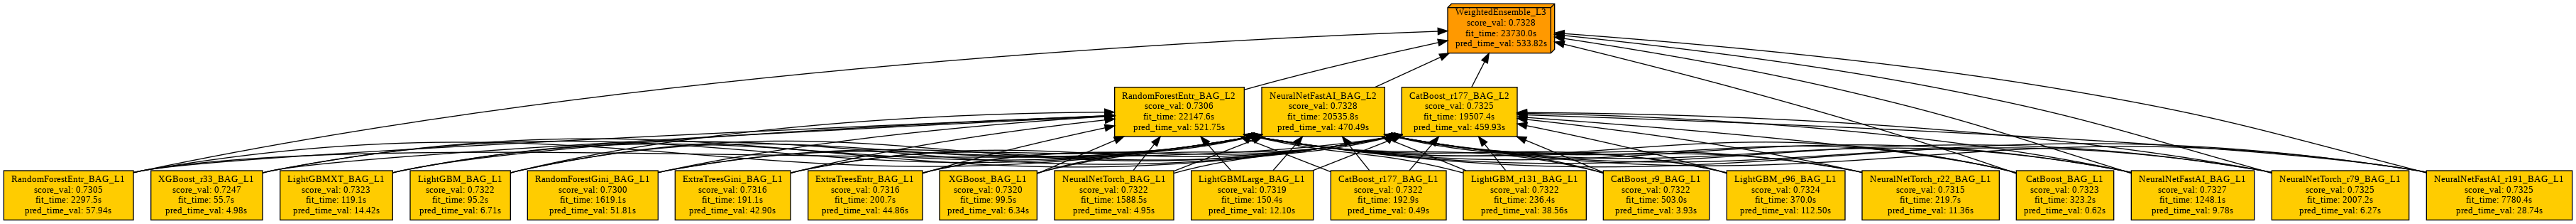

In [17]:
predictor.plot_ensemble_model(filename='ensemble_model.png')
display(Image(f'{MODELS_PATH}ensemble_model.png'))

In [18]:
# !zip -r /kaggle/working/AG_accident_models /kaggle/working/AG_accident_models.zip
# !zip -r {FOLDER}{NAME_EXT}.zip /kaggle/working/{FOLDER}{NAME_EXT}

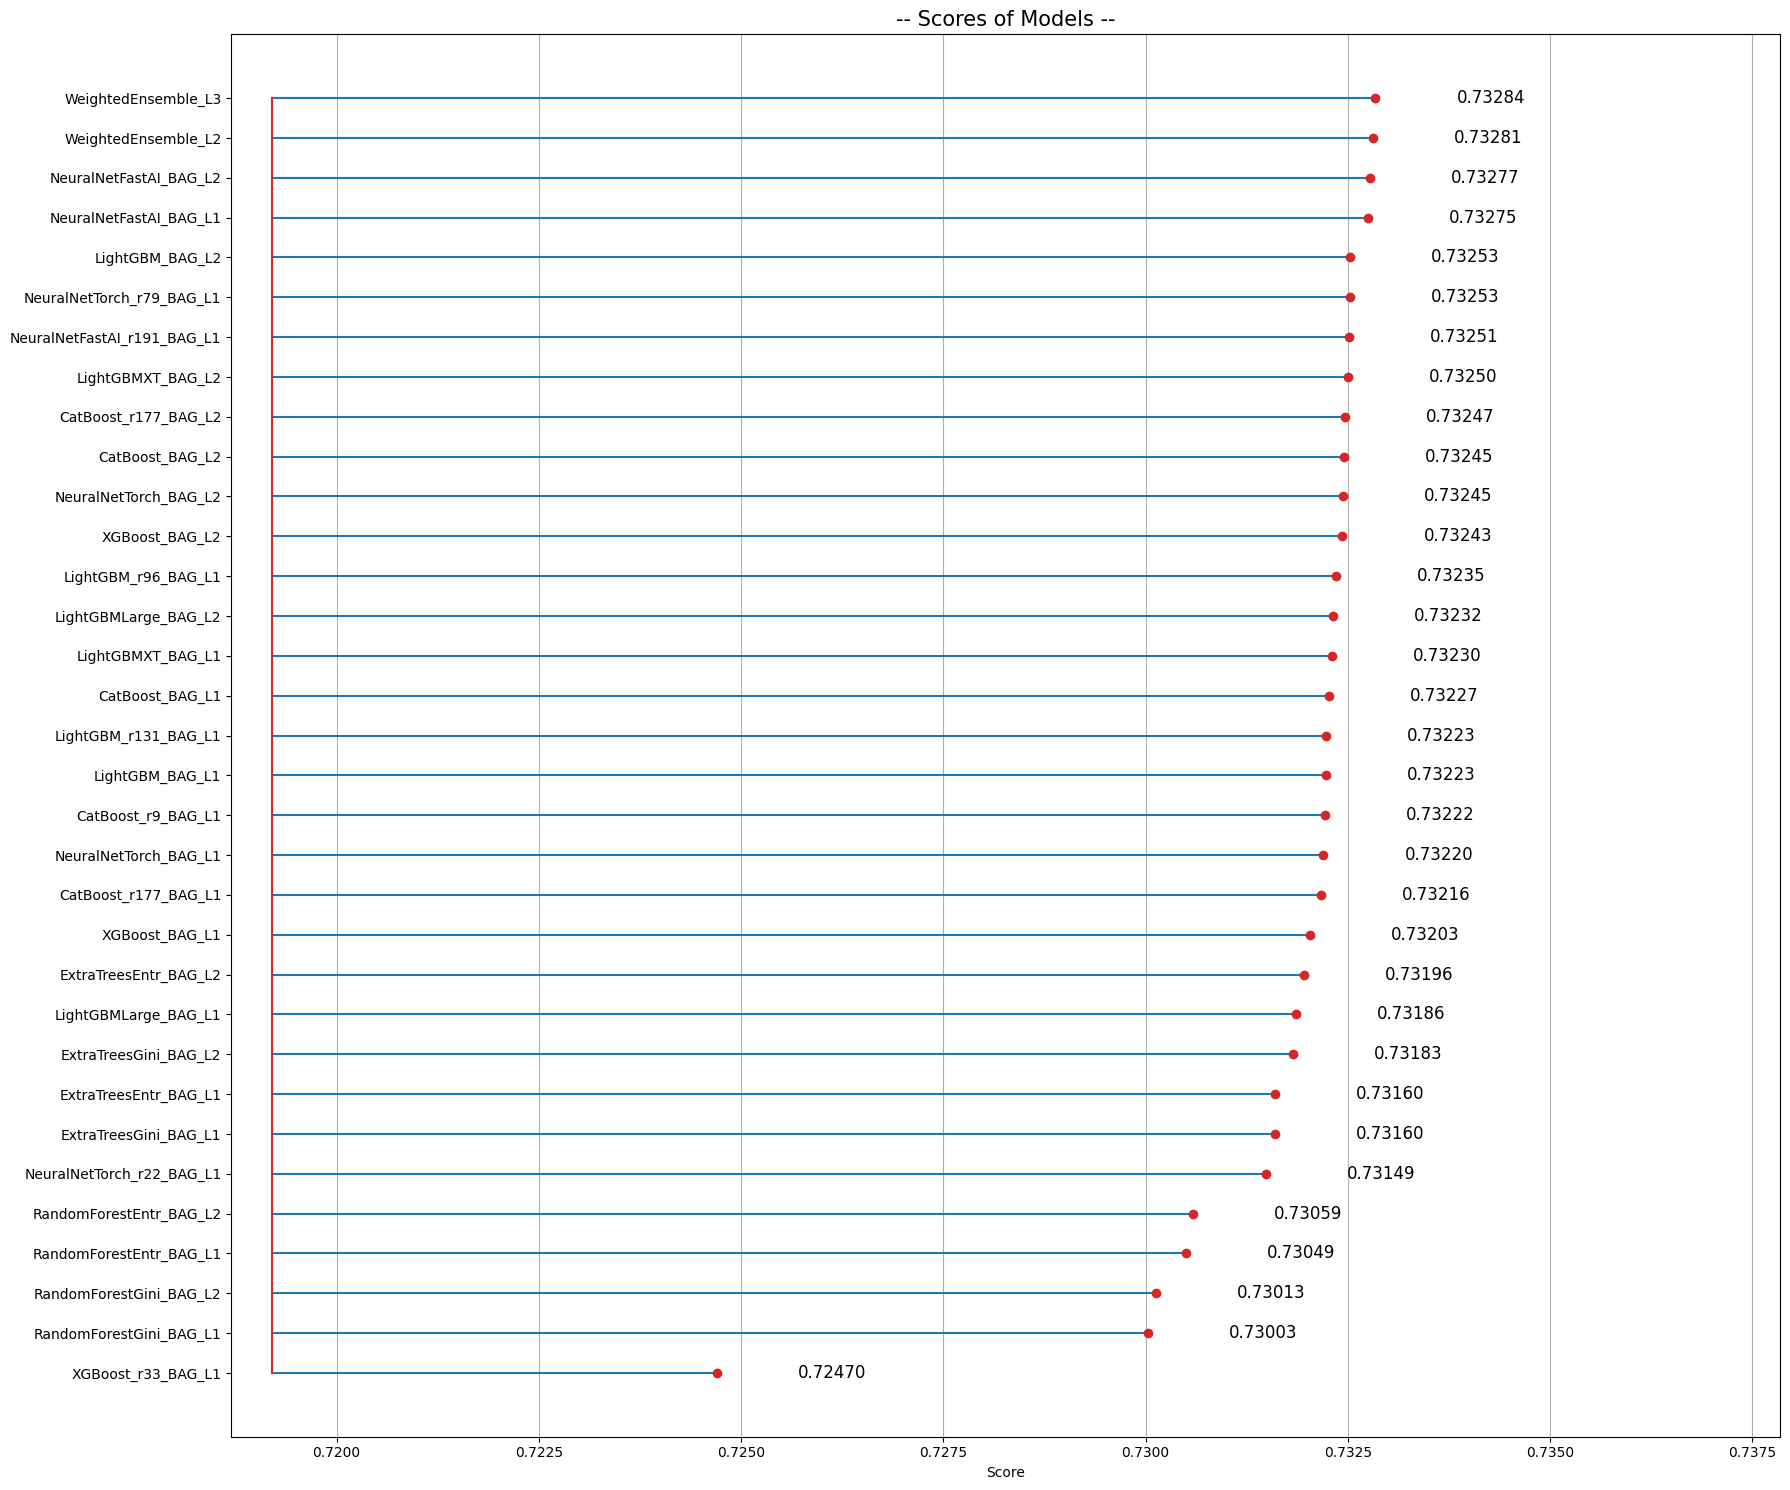

In [19]:
## -- Extract model scores --
result_ = dict(zip(leaderboard['model'], leaderboard['score_val']))
result_df = pd.DataFrame.from_dict(result_, orient='index').sort_values(0)

max_score = result_df.max().item()
min_score = result_df.min().item()

## -- PLOT MODELS & SCORES --
plt.figure(figsize=(18, 15))
plt.stem(
    result_df.index,
    result_df[0],
    orientation = 'horizontal',
    bottom = min_score - 0.0055,
    markerfmt = 'C3o'
)
plt.xlim(min_score - 0.006, max_score + 0.005)
plt.xlabel('Score')
plt.title('-- Scores of Models --', fontsize=15)

for i, value in enumerate(result_df[0]):
    plt.text(value+1e-3, i, f'{abs(value):.5f}', ha='left', va='center', fontdict=dict(size=12))

plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

In [20]:
# predictor.model_names()

In [21]:
# ## -- Permutation Feature Importances --
# feat_imp = predictor.feature_importance(
#                         data = X_test,
#                         # time_limit = 3600,
#                         # model = 'LightGBM_BAG_L1',
#                         # features = None,
#                         # feature_stage = 'transformed',
#                         # subsample_size = 5000,
#                         # num_shuffle_sets = 10,
#                         # include_confidence_band = True,
#                         confidence_level = 0.95,
#                         # silent = False
# ) 

# feat_imp.style.background_gradient(subset=["importance"], cmap="Spectral")

# plt.figure(figsize=(18, 35))
# sns.barplot(data=feat_imp, y=feat_imp.index, x=feat_imp.importance)
# plt.tick_params(axis='y', which='major', labelcolor='r')
# plt.title("Top Features by Permutation")
# plt.tight_layout()
# plt.show()

In [22]:
print(f"""
{'-'*48}
{'█'*5} | - AUTOGLUON NOTEBOOK COMPLETE! - | {'█'*5}
{'-'*48}
""")


------------------------------------------------
█████ | - AUTOGLUON NOTEBOOK COMPLETE! - | █████
------------------------------------------------



In [23]:
## -- OPTIONAL: Remove stored files --
!rm -r {MODELS_PATH}